In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm.auto import tqdm
from scipy.special import logit,expit
import seaborn as sns
# plt.style.use('ggplot')

from correlation_correction.methods import gl_methods as gl
from correlation_correction.methods import hamling_methods as ham
from correlation_correction.regressions import gls_reg, wls_reg, _create_covariance_matrix

In [2]:
# Setting seed
golden_seed = 6
seed = 8
np.random.seed(seed)

# Initializing simulation slope and intercept parameters
beta0 = -0.1
beta1 = 0.02
beta_age = 0.05
beta_income = -0.05
beta_sex = 1.0

# Number of samples
n = 40000

# Constructing covariate vectors for additional covariates to adjust
age_vector = np.random.uniform(low=0,high=1,size=n)
income_vector = np.random.uniform(low=0,high=1,size=n)
# sex_vector = np.random.binomial(n=1,p=0.6,size=n)

# Assigning exposure levels and getting relevant x's
exposure_levels = np.array([0.,1.,2.,3.])
xs = np.random.choice(exposure_levels,size = n)
sex_vector = np.random.binomial(n = 1,p = 0.1 + xs/4,size =n )


# Function to generate probabilities of being a case v non-case
other_covs = beta0 + (beta_age*age_vector) + (income_vector*beta_income) + (sex_vector*beta_sex) 
p = lambda x: (np.exp(beta1*x + other_covs))/(1 + np.exp(beta1*x + other_covs))

# Actually calculating probabilities on exposures as defined
px = p(xs)

# Actually assigning to case or not
outcomes = np.array([np.random.binomial(n=1,p=p,size=1)[0] for p in px])

# Constructing and sorting dataframe of outcomes and exposure
df = np.stack([outcomes,xs],axis=1)
# df = df[np.argsort(df[:, 1])]

# Getting xs corresponding to each exposure interval and corresponding case information
categories = [df[np.where(df[:,1] == i)[0]] for i in exposure_levels]
N = np.array([df.shape[0] for df in categories])
cases = np.array([np.sum(df[:,0]) for df in categories])
non_cases = N - cases
a_0, A = cases[0], cases[1:]
b_0, B = non_cases[0], non_cases[1:]
M = np.sum(cases)
p = b_0 / np.sum(non_cases)
z = np.sum(non_cases) / np.sum(cases)

# Getting crude estimates to compare
crude = lambda x,y: (x/y) / (a_0/b_0)
crudeors = crude(A,B)

# Constructing dummy variables with respect to exposure level
x = exposure_levels[1:]

to_adjust_df = pd.DataFrame({
    'age':age_vector,
    'income':income_vector,
    'sex':sex_vector,
    'exposure':xs.astype(int)
})
to_adjust_df['intercept']=1

to_adjust_df = pd.concat([to_adjust_df,pd.get_dummies(to_adjust_df['exposure'],prefix='exposure').astype(int).iloc[:,1:]],axis=1).drop('exposure',axis=1)

results = sm.Logit(endog=df[:,0], exog=to_adjust_df).fit()
true_C = results.cov_params().to_numpy()[4:,4:]
true_C_inv = np.linalg.inv(true_C)

# Get log-ORs and corresponding variances
L = results.params.to_numpy()[4:]
v = (results.bse.to_numpy()[4:])**2

Optimization terminated successfully.
         Current function value: 0.645992
         Iterations 5


In [3]:
counts_ham = ham.hamling(L,p,z,v)
counts_gl = gl.convex_gl(L,N,M)

In [4]:
b_true, v_true = gls_reg(true_C_inv,L,x)
b_gl, v_gl = gls_reg(np.linalg.inv(counts_gl.cov(v)),L,x)
b_ham, v_ham = gls_reg(np.linalg.inv(counts_ham.cov(v)),L,x)

In [5]:
print(f"This is the true slope: {b_true} and variance: {v_true}")
print(f"This is the GL slope: {b_gl} and variance: {v_gl}")
print(f"This is the Hamling slope: {b_ham} and variance: {v_ham}")

This is the true slope: 0.012455857235796616 and variance: 34.61055266546174
This is the GL slope: 0.012414881379856265 and variance: 35.751662206580555
This is the Hamling slope: 0.012485630362538611 and variance: 38.773273056624426


#### Simulation

In [6]:
GL_pe_list = []
GL_v_list = []
oracle_pe_list = []
oracle_v_list = []
OLS_pe_list = []
OLS_v_list = []
crude_pe_list = []
crude_v_list = []
hamling_pe_list = []
hamling_v_list = []

crude_cov = []
gl_cov = []
ham_cov = []
oracle_cov = []

# Setting seed
# golden_seed = 6
# seed = 8
# np.random.seed(seed)

# Initializing simulation slope and intercept parameters
beta0 = -0.1
beta1 = 0.02
beta_age = 1. # was 1.
beta_income = -0.05
beta_sex = 5.0

# Number of samples
n = 10000

# Simulation number
sim_no = 500

# Running the simulation
for i in tqdm(range(sim_no)):
    # Constructing covariate vectors for additional covariates to adjust
    age_vector = np.random.uniform(low=0,high=1,size=n)
    income_vector = np.random.uniform(low=0,high=1,size=n)
    # sex_vector = np.random.binomial(n=1,p=0.6,size=n)

    # Assigning exposure levels and getting relevant x's
    exposure_levels = np.array([0.,1.,2.,3.])
    xs = np.random.choice(exposure_levels,size = n,p = np.array([0.02,0.33,0.33,0.32]))
    sex_vector = np.random.binomial(n = 1,p = 0.1 + xs/4,size =n )


    # Function to generate probabilities of being a case v non-case
    other_covs = beta0 + (beta_age*age_vector) + (income_vector*beta_income) + (sex_vector*beta_sex) 
    #p = lambda x: (np.exp(beta1*x + other_covs))/(1 + np.exp(beta1*x + other_covs))
    px = (expit(beta1*xs+other_covs))

    # Actually calculating probabilities on exposures as defined
    #px = p(xs)

    # Actually assigning to case or not
    outcomes = np.array([np.random.binomial(n=1,p=p,size=1)[0] for p in px])

    # Constructing and sorting dataframe of outcomes and exposure
    df = np.stack([outcomes,xs],axis=1)
    # df = df[np.argsort(df[:, 1])]

    # Getting xs corresponding to each exposure interval and corresponding case information
    categories = [df[np.where(df[:,1] == i)[0]] for i in exposure_levels]
    N = np.array([df.shape[0] for df in categories])
    cases = np.array([np.sum(df[:,0]) for df in categories])
    non_cases = N - cases
    a_0, A = cases[0], cases[1:]
    b_0, B = non_cases[0], non_cases[1:]
    M = np.sum(cases)
    p = b_0 / np.sum(non_cases)
    z = np.sum(non_cases) / np.sum(cases)

    # Getting crude estimates to compare
    crude = lambda x,y: (x/y) / (a_0/b_0)
    crudeors = crude(A,B)

    # Constructing dummy variables with respect to exposure level
    x = exposure_levels[1:]

    to_adjust_df = pd.DataFrame({
        'age':age_vector,
        'income':income_vector,
        'sex':sex_vector,
        'exposure':xs.astype(int)
    })
    to_adjust_df['intercept']=1

    to_adjust_df = pd.concat([to_adjust_df,pd.get_dummies(to_adjust_df['exposure'],prefix='exposure').astype(int).iloc[:,1:]],axis=1).drop('exposure',axis=1)

    results = sm.Logit(endog=outcomes, exog=to_adjust_df).fit(disp=0)
    num_exposures = len(exposure_levels)-1
    true_C = results.cov_params().to_numpy()[-num_exposures:,-num_exposures:]
    true_C_inv = np.linalg.inv(true_C)

    # Get log-ORs and corresponding variances
    L = results.params.to_numpy()[-num_exposures:]
    v = (results.bse.to_numpy()[-num_exposures:])**2

    # Get counts according to hamling and gl
    counts_ham = ham.hamling(L,p,z,v)
    counts_gl = gl.convex_gl(L,N,M)

    # Get GL statistics
    cov_gl = counts_gl.cov(v)
    gl_cov.append(cov_gl)
    b_gl, v_gl = gls_reg(cov_gl,L,x)
    GL_pe_list.append(b_gl)
    GL_v_list.append(v_gl)

    # Get Hamling statistics
    cov_ham = counts_ham.cov(v)
    ham_cov.append(cov_ham)
    b_ham, v_ham = gls_reg(cov_ham,L,x)
    hamling_pe_list.append(b_ham)
    hamling_v_list.append(v_ham)

    # Append true statistics
    oracle_cov.append(true_C)
    b_true, v_true = gls_reg(true_C,L,x)
    oracle_pe_list.append(b_true)
    oracle_v_list.append(v_true)

    # Append crude statistics
    cov_crude = _create_covariance_matrix(A,B,a_0,b_0,v)
    crude_cov.append(cov_crude)
    b_crude, v_crude = gls_reg(cov_crude,L,x)
    crude_pe_list.append(b_crude)
    crude_v_list.append(v_crude)

    # Append WLS statistics
    b_wls, v_wls = wls_reg(L,x,v)
    OLS_pe_list.append(b_wls)
    OLS_v_list.append(v_wls)


  0%|          | 0/500 [00:00<?, ?it/s]

In [9]:
def mean_sq_error(cov_list1,cov_list2):
    cov_list1, cov_list2 = np.array(cov_list1),np.array(cov_list2)
    list_sq_error = (cov_list1 - cov_list2)**2
    msqerror = np.mean(list_sq_error,axis=0)
    msqerror[msqerror < 1e-12] = 0
    return msqerror

def mean_abs_error(cov_list1,cov_list2):
    cov_list1, cov_list2 = np.array(cov_list1),np.array(cov_list2)
    list_abs_error = np.abs(cov_list1 - cov_list2)
    mabserror = np.mean(list_abs_error,axis=0)
    mabserror[mabserror < 1e-12] = 0
    return mabserror

# def rel_error(cov_list1,cov_list2):
    

In [26]:
plt.style.use("ggplot")

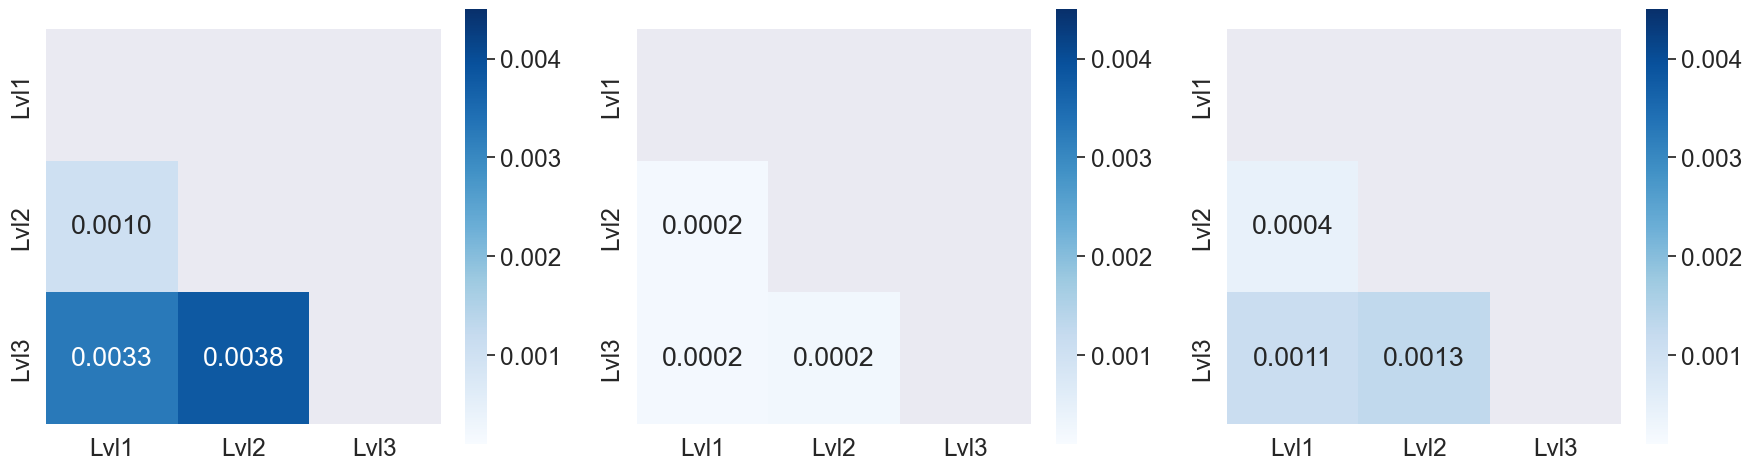

In [31]:
C_gl = mean_abs_error(gl_cov,oracle_cov)
C_ham = mean_abs_error(ham_cov,oracle_cov)
C_crude = mean_abs_error(crude_cov,oracle_cov)

fig, axes = plt.subplots(1,3,figsize=(18, 5))

mask = np.triu(np.ones_like(C_gl, dtype=bool))  # Mask for the upper triangle
# plt.figure(figsize=(8, 6))
sns.set_theme(font_scale=1.6)
sns.heatmap(C_gl, annot=True, mask=mask, cmap='Blues', cbar=True, square=True,  fmt=".4f",
            xticklabels=[f'Lvl{i+1}' for i in range(3)], 
            yticklabels=[f'Lvl{i+1}' for i in range(3)], vmin=.0001,vmax=0.0045,ax=axes[0])
axes[0].grid(False)

sns.heatmap(C_ham, annot=True, mask=mask, cmap='Blues', cbar=True, square=True,  fmt=".4f",
            xticklabels=[f'Lvl{i+1}' for i in range(3)], 
            yticklabels=[f'Lvl{i+1}' for i in range(3)], vmin=.0001,vmax=0.0045,ax=axes[1])
axes[1].grid(False)


sns.heatmap(C_crude, annot=True, mask=mask, cmap='Blues', cbar=True, square=True,  fmt=".4f",
            xticklabels=[f'Lvl{i+1}' for i in range(3)], 
            yticklabels=[f'Lvl{i+1}' for i in range(3)], vmin=.0001,vmax=0.0045,ax=axes[2])
axes[2].grid(False)

plt.tight_layout()
# plt.title('Upper Triangle of Covariance Matrix--Convex GL')
plt.savefig("../images/MAE_cov_mat.pdf")
plt.show()

In [10]:
print(f"This is the entry-wise MSE between the oracle and crude: \n{mean_sq_error(crude_cov,oracle_cov)}")
print(f"This is the entry-wise MAE between the oracle and crude: \n{mean_abs_error(crude_cov,oracle_cov)}")

This is the entry-wise MSE between the oracle and crude: 
[[0.00000000e+00 1.94852254e-07 1.26324136e-06]
 [1.94852254e-07 0.00000000e+00 1.62031371e-06]
 [1.26324136e-06 1.62031371e-06 0.00000000e+00]]
This is the entry-wise MAE between the oracle and crude: 
[[0.         0.00043971 0.00111987]
 [0.00043971 0.         0.0012688 ]
 [0.00111987 0.0012688  0.        ]]


In [11]:
print(f"This is the entry-wise MSE between the oracle and GL: \n{mean_sq_error(gl_cov,oracle_cov)}")
print(f"This is the entry-wise MAE between the oracle and GL: \n{mean_abs_error(gl_cov,oracle_cov)}")

This is the entry-wise MSE between the oracle and GL: 
[[0.00000000e+00 1.05257032e-06 1.06895461e-05]
 [1.05257032e-06 0.00000000e+00 1.45710406e-05]
 [1.06895461e-05 1.45710406e-05 0.00000000e+00]]
This is the entry-wise MAE between the oracle and GL: 
[[0.         0.00101925 0.00326284]
 [0.00101925 0.         0.00381121]
 [0.00326284 0.00381121 0.        ]]


In [12]:
print(f"This is the entry-wise MSE between the oracle and Hamling: \n{mean_sq_error(ham_cov,oracle_cov)}")
print(f"This is the entry-wise MAE between the oracle and Hamling: \n{mean_abs_error(ham_cov,oracle_cov)}")

This is the entry-wise MSE between the oracle and Hamling: 
[[0.00000000e+00 6.67480247e-07 6.64868009e-07]
 [6.67480247e-07 0.00000000e+00 6.62053406e-07]
 [6.64868009e-07 6.62053406e-07 0.00000000e+00]]
This is the entry-wise MAE between the oracle and Hamling: 
[[0.         0.00018723 0.0001963 ]
 [0.00018723 0.         0.00024615]
 [0.0001963  0.00024615 0.        ]]


In [13]:
np.mean(crude_cov,axis=0)

array([[0.02556671, 0.02405734, 0.02476063],
       [0.02405734, 0.02677697, 0.02497882],
       [0.02476063, 0.02497882, 0.03202072]])

In [14]:
np.mean(gl_cov,axis=0)

array([[0.02556671, 0.02463689, 0.0269036 ],
       [0.02463689, 0.02677697, 0.02752123],
       [0.0269036 , 0.02752123, 0.03202072]])

In [15]:
np.mean(ham_cov,axis=0)

array([[0.02556671, 0.02369707, 0.02369707],
       [0.02369707, 0.02677697, 0.02369707],
       [0.02369707, 0.02369707, 0.03202072]])

In [16]:
np.mean(oracle_cov,axis=0)

array([[0.02556671, 0.02361764, 0.02364076],
       [0.02361764, 0.02677697, 0.02371002],
       [0.02364076, 0.02371002, 0.03202072]])

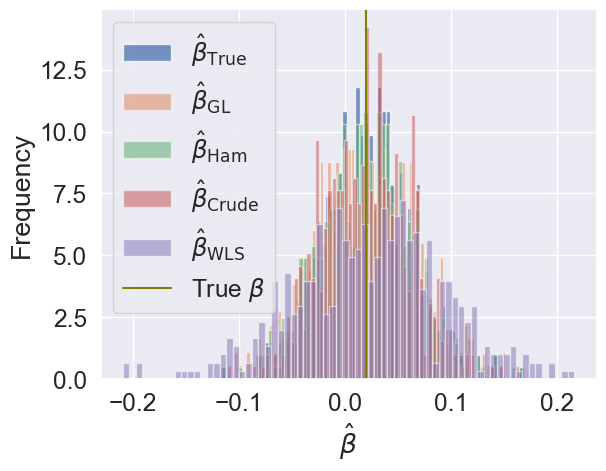

In [21]:
# plt.figure(figsize=(4,3))
# plt.hist(results[:,0],50,alpha = 0.5,density=True,label=r"$\hat\beta_{\mathrm{GLS}}$")
# plt.hist(results[:,1],50,alpha = 0.5,density=True,label=r"$\hat\beta_{\mathrm{WLS}}$")
plt.hist(oracle_pe_list,70,alpha=0.75,density=True,label=r"$\hat\beta_{\mathrm{True}}$")
plt.hist(GL_pe_list,70,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{GL}}$")
plt.hist(hamling_pe_list,70,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{Ham}}$")
plt.hist(crude_pe_list,70,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{Crude}}$")
plt.hist(OLS_pe_list,70,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{WLS}}$")
plt.axvline(x = 0.02, color = 'olive', label = r'True $\beta$')
plt.xlabel(r"$\hat \beta$")
plt.ylabel("Frequency")
plt.legend()
# plt.savefig("images/distribution_plot.pdf",bbox_inches="tight",pad_inches=0.1)
plt.show()

In [107]:
print(f"This is the mean point estimate for the oracle: {np.mean(oracle_pe_list)}")
print(f"This is the mean point estimate for GL: {np.mean(GL_pe_list)}")
print(f"This is the mean point estimate for Hamling: {np.mean(hamling_pe_list)}")
print(f"This is the mean point estimate for the crude: {np.mean(crude_pe_list)}")
print(f"This is the mean point estimate for the WLS: {np.mean(OLS_pe_list)}")

This is the mean point estimate for the oracle: 0.01917469839012156
This is the mean point estimate for GL: 0.01964234240078312
This is the mean point estimate for Hamling: 0.019804054098500622
This is the mean point estimate for the crude: 0.018901414981169998
This is the mean point estimate for the WLS: 0.020904073175552276


In [108]:
print(f"This is the mean variance for the oracle: {np.mean(oracle_v_list)}")
print(f"This is the mean variance for GL: {np.mean(GL_v_list)}")
print(f"This is the mean variance for Hamling: {np.mean(hamling_v_list)}")
print(f"This is the mean variance for the crude: {np.mean(crude_v_list)}")
print(f"This is the mean variance for the WLS: {np.mean(OLS_v_list)}")

This is the mean variance for the oracle: 0.0017460232810579106
This is the mean variance for GL: 0.0009303601764114422
This is the mean variance for Hamling: 0.0016241520122309177
This is the mean variance for the crude: 0.0012665557348614
This is the mean variance for the WLS: 0.002210233896541434


In [109]:
print(f"This is the variance of the point estimates for the oracle: {np.var(oracle_pe_list)}")
print(f"This is the variance of the point estimates for GL: {np.var(GL_pe_list)}")
print(f"This is the variance of the point estimates for Hamling: {np.var(hamling_pe_list)}")
print(f"This is the variance of the point estimates for the crude: {np.var(crude_pe_list)}")
print(f"This is the variance of the point estimates for the WLS: {np.var(OLS_pe_list)}")

This is the variance of the point estimates for the oracle: 0.0018353331890647055
This is the variance of the point estimates for GL: 0.002293894870883263
This is the variance of the point estimates for Hamling: 0.00196320191482657
This is the variance of the point estimates for the crude: 0.0019246792973175088
This is the variance of the point estimates for the WLS: 0.005565336292826433


In [110]:
print(f"This is the sd of variance for the oracle: {np.std(oracle_v_list)}")
print(f"This is the sd of variance for GL: {np.std(GL_v_list)}")
print(f"This is the sd of variance for Hamling: {np.std(hamling_v_list)}")
print(f"This is the sd of variance for the crude: {np.std(crude_v_list)}")
print(f"This is the sd of variance for the WLS: {np.std(OLS_v_list)}")

This is the sd of variance for the oracle: 4.517211123461208e-05
This is the sd of variance for GL: 8.668892799460197e-05
This is the sd of variance for Hamling: 0.0005752096546720165
This is the sd of variance for the crude: 4.4208110844986816e-05
This is the sd of variance for the WLS: 0.00015623897260481432
